In [1]:
# Cell 1: Imports
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from lib.layers import Dense
from lib.activations import ReLU, Sigmoid, Tanh, Softmax
from lib.losses import MSE
from lib.optimizer import SGD
from lib.network import Sequential

print("Library imported successfully!")


Library imported successfully!


In [2]:
# Cell 2: Gradient Checking Function
def gradient_checking(layer, X, epsilon=1e-7):
    
    print("=" * 60)
    print("GRADIENT CHECKING")
    print("=" * 60)
    
    # Forward pass
    output = layer.forward(X)
    
    # Create arbitrary gradient (simulating gradient from next layer)
    output_gradient = np.ones_like(output)
    
    # Backward pass to get analytical gradients
    layer.backward(output_gradient)
    
    if hasattr(layer, 'weights'):
        analytical_grad = layer.weights_gradient
        numerical_grad = np.zeros_like(layer.weights)
        
        # Compute numerical gradient for each weight
        print(f"Computing numerical gradients for {layer.weights.size} parameters...")
        
        it = np.nditer(layer.weights, flags=['multi_index'], op_flags=['readwrite'])
        while not it.finished:
            idx = it.multi_index
            
            old_value = layer.weights[idx]
            
            # f(x + epsilon)
            layer.weights[idx] = old_value + epsilon
            output_plus = np.sum(layer.forward(X))
            
            # f(x - epsilon)
            layer.weights[idx] = old_value - epsilon
            output_minus = np.sum(layer.forward(X))
            
            # Numerical gradient: [f(x+ε) - f(x-ε)] / (2ε)
            numerical_grad[idx] = (output_plus - output_minus) / (2 * epsilon)
            
            # Restore original value
            layer.weights[idx] = old_value
            
            it.iternext()
        
        # Compare gradients
        difference = np.linalg.norm(analytical_grad - numerical_grad) / (
            np.linalg.norm(analytical_grad) + np.linalg.norm(numerical_grad)
        )
        
        print(f"\nAnalytical Gradient (sample):\n{analytical_grad[:2, :2]}")
        print(f"\nNumerical Gradient (sample):\n{numerical_grad[:2, :2]}")
        print(f"\nRelative difference: {difference:.10f}")
        
        if difference < 1e-5:
            print("Gradient check PASSED! Backpropagation is correct.")
        else:
            print(" Gradient check FAILED! Check your backward() implementation.")
        
        return difference
    else:
        print("Layer has no parameters to check.")

In [3]:
# Cell 3: Test Gradient Checking
print("Testing Dense Layer Gradient Checking:\n")
test_layer = Dense(3, 2)
test_input = np.random.randn(5, 3)
gradient_checking(test_layer, test_input)

Testing Dense Layer Gradient Checking:

GRADIENT CHECKING
Computing numerical gradients for 6 parameters...

Analytical Gradient (sample):
[[-1.89659194 -1.89659194]
 [-1.25877589 -1.25877589]]

Numerical Gradient (sample):
[[-1.89659194 -1.89659194]
 [-1.25877589 -1.25877589]]

Relative difference: 0.0000000003
Gradient check PASSED! Backpropagation is correct.


np.float64(3.425217802963101e-10)

In [4]:
# Cell 4: XOR Dataset
print("\n" + "=" * 60)
print("XOR PROBLEM")
print("=" * 60)

# XOR truth table
X_xor = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]], dtype=float)

y_xor = np.array([[0],
                  [1],
                  [1],
                  [0]], dtype=float)

print("\nXOR Dataset:")
print("-" * 30)
for i in range(len(X_xor)):
    print(f"Input: {X_xor[i]} → Target: {y_xor[i][0]}")


XOR PROBLEM

XOR Dataset:
------------------------------
Input: [0. 0.] → Target: 0.0
Input: [0. 1.] → Target: 1.0
Input: [1. 0.] → Target: 1.0
Input: [1. 1.] → Target: 0.0


In [5]:
# Cell 5: Build and Train XOR Network
print("\n" + "=" * 60)
print("Building Network: 2 → 4 → 1")
print("=" * 60)

# Create model
model = Sequential()
model.add(Dense(2, 4))      # 2 inputs → 4 hidden neurons
model.add(Tanh())            # Tanh activation
model.add(Dense(4, 1))       # 4 hidden → 1 output
model.add(Sigmoid())         # Sigmoid output (0 to 1)

# Compile
optimizer = SGD(learning_rate=0.1)
loss = MSE()
model.compile(loss=loss, optimizer=optimizer)

print("\nModel architecture:")
print("- Input Layer: 2 neurons")
print("- Hidden Layer: 4 neurons (Tanh activation)")
print("- Output Layer: 1 neuron (Sigmoid activation)")
print(f"- Optimizer: SGD (lr={optimizer.learning_rate})")
print("- Loss: MSE")

# Train
print("\n" + "=" * 60)
print("Training...")
print("=" * 60)

history = model.fit(X_xor, y_xor, epochs=5000, verbose=True)


Building Network: 2 → 4 → 1

Model architecture:
- Input Layer: 2 neurons
- Hidden Layer: 4 neurons (Tanh activation)
- Output Layer: 1 neuron (Sigmoid activation)
- Optimizer: SGD (lr=0.1)
- Loss: MSE

Training...
Epoch 1/5000 - Loss: 0.283308
Epoch 101/5000 - Loss: 0.232706
Epoch 201/5000 - Loss: 0.206702
Epoch 301/5000 - Loss: 0.186074
Epoch 401/5000 - Loss: 0.166634
Epoch 501/5000 - Loss: 0.145607
Epoch 601/5000 - Loss: 0.122339
Epoch 701/5000 - Loss: 0.098899
Epoch 801/5000 - Loss: 0.077774
Epoch 901/5000 - Loss: 0.060447
Epoch 1001/5000 - Loss: 0.047139
Epoch 1101/5000 - Loss: 0.037260
Epoch 1201/5000 - Loss: 0.029995
Epoch 1301/5000 - Loss: 0.024620
Epoch 1401/5000 - Loss: 0.020586
Epoch 1501/5000 - Loss: 0.017505
Epoch 1601/5000 - Loss: 0.015107
Epoch 1701/5000 - Loss: 0.013209
Epoch 1801/5000 - Loss: 0.011680
Epoch 1901/5000 - Loss: 0.010431
Epoch 2001/5000 - Loss: 0.009395
Epoch 2101/5000 - Loss: 0.008527
Epoch 2201/5000 - Loss: 0.007791
Epoch 2301/5000 - Loss: 0.007160
Epoc

In [6]:
# Cell 6: XOR Results
print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)

predictions = model.predict(X_xor)

print("\nPredictions:")
print("-" * 50)
print(f"{'Input':<15} {'Prediction':<15} {'Target':<10}")
print("-" * 50)

for i in range(len(X_xor)):
    pred_val = predictions[i][0]
    target_val = y_xor[i][0]
    print(f"{str(X_xor[i]):<15} {pred_val:>8.4f}       {target_val:>8.0f}")

# Binary accuracy
predictions_binary = (predictions > 0.5).astype(int)
accuracy = np.mean(predictions_binary == y_xor)
print(f"\nBinary Accuracy: {accuracy * 100:.2f}%")



FINAL RESULTS

Predictions:
--------------------------------------------------
Input           Prediction      Target    
--------------------------------------------------
[0. 0.]           0.0231              0
[0. 1.]           0.9526              1
[1. 0.]           0.9546              1
[1. 1.]           0.0577              0

Binary Accuracy: 100.00%


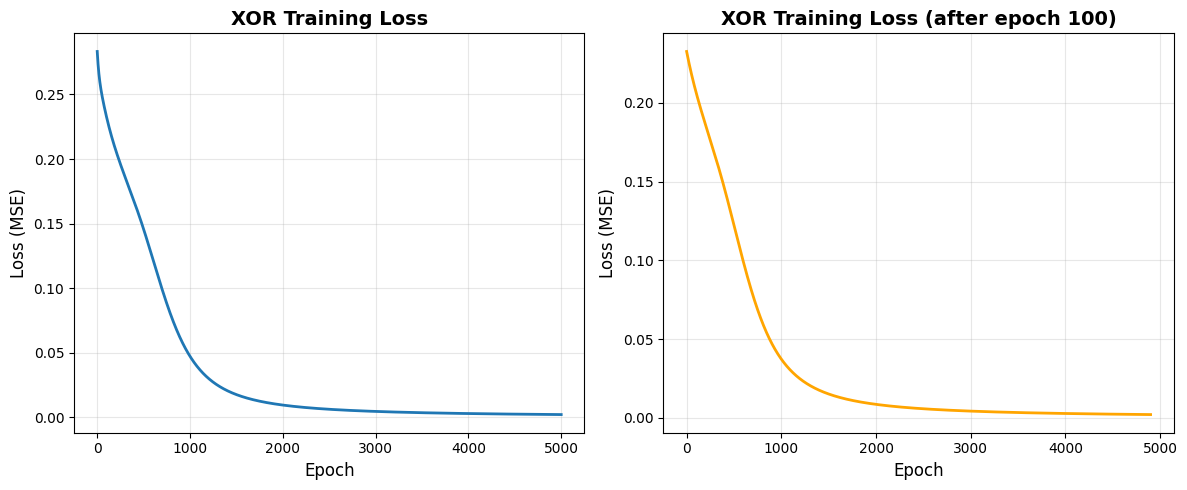

In [7]:
# Cell 7: Plot Training Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('XOR Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['loss'][100:], linewidth=2, color='orange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('XOR Training Loss (after epoch 100)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [8]:
# Cell 8 (IMPROVED): Load MNIST Dataset with More Data
print("=" * 60)
print("PHASE 2: IMPROVED AUTOENCODER IMPLEMENTATION")
print("=" * 60)

from tensorflow.keras.datasets import mnist

# Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("\n Dataset Information:")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Preprocess data
X_train_flat = X_train.reshape(-1, 784).astype('float32')
X_test_flat = X_test.reshape(-1, 784).astype('float32')

# Normalize to [0, 1]
X_train_flat /= 255.0
X_test_flat /= 255.0

# Use MORE data for better learning
n_train = 30000  # INCREASED from 10000
n_test = 5000    # INCREASED from 2000

X_train_subset = X_train_flat[:n_train]
X_test_subset = X_test_flat[:n_test]

print(f"\n  Using LARGER subset: {n_train} training, {n_test} test samples")
print("  More data = Better reconstruction quality")


PHASE 2: IMPROVED AUTOENCODER IMPLEMENTATION

 Dataset Information:
Training samples: 60000
Test samples: 10000

  Using LARGER subset: 30000 training, 5000 test samples
  More data = Better reconstruction quality


In [9]:
# Cell 9 (IMPROVED): Build Better Autoencoder Architecture
print("\n" + "=" * 60)
print("BUILDING IMPROVED AUTOENCODER")
print("=" * 60)

from lib import Dense, ReLU, Sigmoid, MSE, SGD, Sequential

# Create autoencoder with LARGER latent space
# Architecture: 784 -> 256 -> 128 -> 64 -> 128 -> 256 -> 784
autoencoder = Sequential()

print("\n Encoder Layers (Improved):")
autoencoder.add(Dense(784, 256))  # Wider first layer
print("  Dense(784 -> 256)")
autoencoder.add(ReLU())
print("  ReLU()")

autoencoder.add(Dense(256, 128))
print("  Dense(256 -> 128)")
autoencoder.add(ReLU())
print("  ReLU()")

autoencoder.add(Dense(128, 64))  # LARGER latent space (was 32)
print("  Dense(128 -> 64) [Latent Space - LARGER]")
autoencoder.add(ReLU())
print("  ReLU()")

print("\n  Decoder Layers (Improved):")
autoencoder.add(Dense(64, 128))
print("  Dense(64 -> 128)")
autoencoder.add(ReLU())
print("  ReLU()")

autoencoder.add(Dense(128, 256))
print("  Dense(128 -> 256)")
autoencoder.add(ReLU())
print("  ReLU()")

autoencoder.add(Dense(256, 784))
print("  Dense(256 -> 784)")
autoencoder.add(Sigmoid())
print("  Sigmoid() [Output]")

# Compile with LOWER learning rate for smoother convergence
autoencoder.compile(
    loss=MSE(),
    optimizer=SGD(learning_rate=0.005)  # REDUCED from 0.01
)

print("\n  Improved Autoencoder built!")
print(f"Total layers: {len(autoencoder.layers)}")
print("\n Improvements:")
print("  • Wider architecture (784→256→128→64)")
print("  • Larger latent space (64 vs 32 dimensions)")
print("  • Lower learning rate (0.005 vs 0.01)")
print("  • More training data (30k vs 10k samples)")



BUILDING IMPROVED AUTOENCODER

 Encoder Layers (Improved):
  Dense(784 -> 256)
  ReLU()
  Dense(256 -> 128)
  ReLU()
  Dense(128 -> 64) [Latent Space - LARGER]
  ReLU()

  Decoder Layers (Improved):
  Dense(64 -> 128)
  ReLU()
  Dense(128 -> 256)
  ReLU()
  Dense(256 -> 784)
  Sigmoid() [Output]

  Improved Autoencoder built!
Total layers: 12

 Improvements:
  • Wider architecture (784→256→128→64)
  • Larger latent space (64 vs 32 dimensions)
  • Lower learning rate (0.005 vs 0.01)
  • More training data (30k vs 10k samples)


In [10]:
# Cell 10 (IMPROVED): Train with More Epochs
print("\n" + "=" * 60)
print("TRAINING IMPROVED AUTOENCODER")
print("=" * 60)

import time

print("\n Training Configuration:")
print(f"  Epochs: 100 (DOUBLED)")  # INCREASED from 50
print(f"  Batch Size: 128")
print(f"  Learning Rate: 0.005 (REDUCED)")
print(f"  Training Samples: {len(X_train_subset)}")
print(f"\n  Starting training \n")

start_time = time.time()

# Train with MORE epochs
history_ae = autoencoder.fit(
    X_train_subset,
    X_train_subset,
    epochs=100,  # INCREASED from 50
    batch_size=128,
    verbose=True
)

training_time = time.time() - start_time

print(f"\n Training completed in {training_time:.2f} seconds")
print(f"Final Loss: {history_ae['loss'][-1]:.6f}")




TRAINING IMPROVED AUTOENCODER

 Training Configuration:
  Epochs: 100 (DOUBLED)
  Batch Size: 128
  Learning Rate: 0.005 (REDUCED)
  Training Samples: 30000

  Starting training 

Epoch 1/100 - Loss: 0.073664
Epoch 100/100 - Loss: 0.009682

 Training completed in 374.38 seconds
Final Loss: 0.009682



TRAINING VISUALIZATION


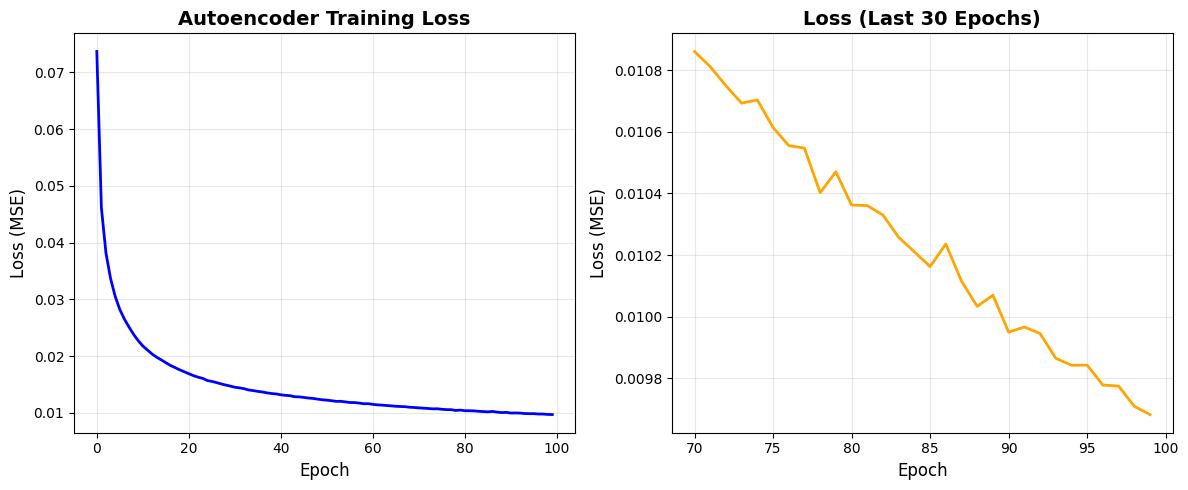


 Training curves displayed


In [11]:
# Cell 11: Visualize Training Progress
print("\n" + "=" * 60)
print("TRAINING VISUALIZATION")
print("=" * 60)

plt.figure(figsize=(12, 5))

# Plot 1: Full training curve
plt.subplot(1, 2, 1)
plt.plot(history_ae['loss'], linewidth=2, color='blue')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Autoencoder Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 2: Last 30 epochs (zoomed) - CHANGED
plt.subplot(1, 2, 2)
plt.plot(range(70, 100), history_ae['loss'][70:], linewidth=2, color='orange')  # Changed from range(30, 50)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Loss (Last 30 Epochs)', fontsize=14, fontweight='bold')  # Updated title
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Training curves displayed")

In [12]:
# Cell 12: Test Reconstruction Quality

# Get predictions on test set
reconstructed = autoencoder.predict(X_test_subset)

# Calculate test loss
test_loss = MSE.loss(X_test_subset, reconstructed)
print(f"\n Test Loss (MSE): {test_loss:.6f}")

# Calculate per-image reconstruction error
reconstruction_errors = np.mean(np.square(X_test_subset - reconstructed), axis=1)
print(f"\n Reconstruction Error Statistics:")
print(f"  Mean Error: {np.mean(reconstruction_errors):.6f}")
print(f"  Std Error: {np.std(reconstruction_errors):.6f}")
print(f"  Min Error: {np.min(reconstruction_errors):.6f}")
print(f"  Max Error: {np.max(reconstruction_errors):.6f}")



 Test Loss (MSE): 0.010157

 Reconstruction Error Statistics:
  Mean Error: 0.010157
  Std Error: 0.005409
  Min Error: 0.000886
  Max Error: 0.042411


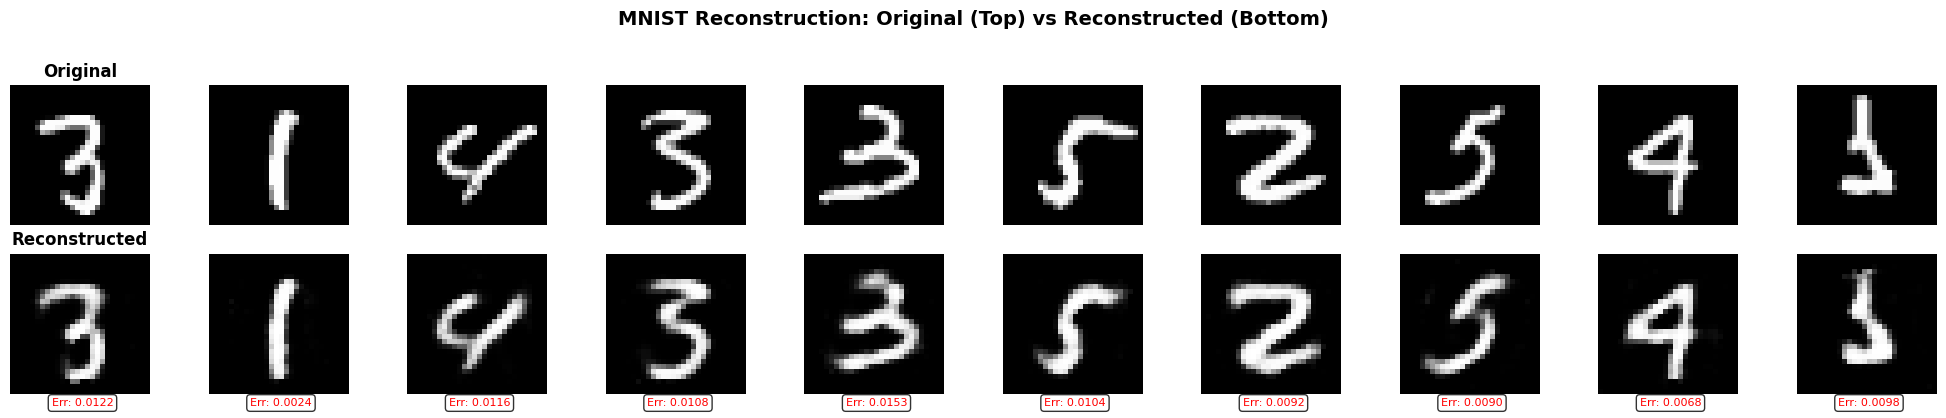


 Visualization complete
Displayed 10 random test samples


In [32]:
# Cell 13: Visualize Original vs Reconstructed Images

# Select random samples to display
n_display = 10
random_indices = np.random.choice(len(X_test_subset), n_display, replace=False)

fig, axes = plt.subplots(2, n_display, figsize=(20, 4))

for i, idx in enumerate(random_indices):
    # Original image
    original_img = X_test_subset[idx].reshape(28, 28)
    axes[0, i].imshow(original_img, cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=12, fontweight='bold')
    
    # Reconstructed image
    reconstructed_img = reconstructed[idx].reshape(28, 28)
    axes[1, i].imshow(reconstructed_img, cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstructed', fontsize=12, fontweight='bold')
    
    # Show reconstruction error
    error = reconstruction_errors[idx]
    axes[1, i].text(14, 30, f'Err: {error:.4f}', 
                    ha='center', fontsize=8, color='red',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('MNIST Reconstruction: Original (Top) vs Reconstructed (Bottom)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n Visualization complete")
print(f"Displayed {n_display} random test samples")


 Average Reconstruction Error by Digit:
----------------------------------------
Digit 0: 0.010169 ██████████
Digit 1: 0.002791 ██
Digit 2: 0.012597 ████████████
Digit 3: 0.010853 ██████████
Digit 4: 0.010145 ██████████
Digit 5: 0.012395 ████████████
Digit 6: 0.011311 ███████████
Digit 7: 0.009738 █████████
Digit 8: 0.013689 █████████████
Digit 9: 0.009191 █████████


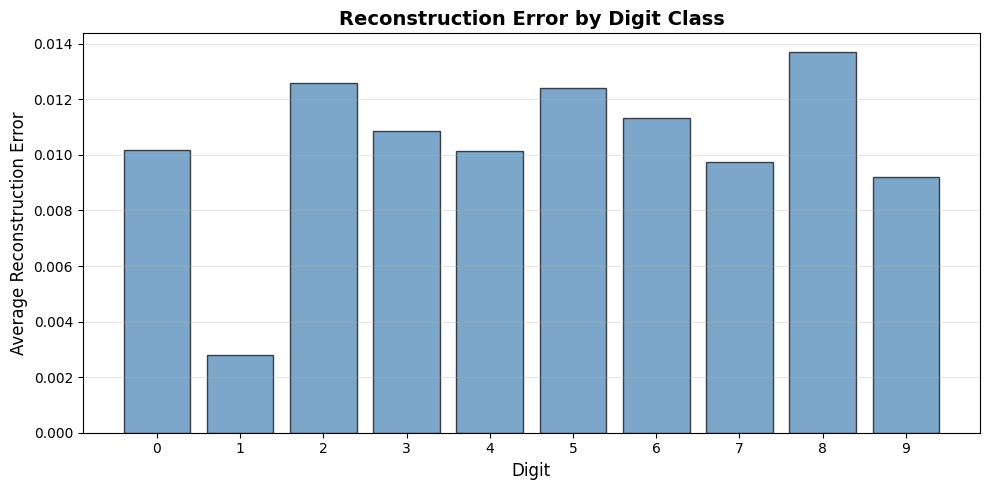


 Analysis complete


In [14]:
# Cell 14: Analyze Reconstruction by Digit

# Calculate average reconstruction error for each digit
y_test_subset = y_test[:n_test]
digit_errors = {}

for digit in range(10):
    digit_mask = (y_test_subset == digit)
    digit_errors[digit] = np.mean(reconstruction_errors[digit_mask])

print("\n Average Reconstruction Error by Digit:")
print("-" * 40)
for digit, error in sorted(digit_errors.items()):
    bar = "█" * int(error * 1000)
    print(f"Digit {digit}: {error:.6f} {bar}")

# Visualize
plt.figure(figsize=(10, 5))
digits = list(digit_errors.keys())
errors = list(digit_errors.values())

plt.bar(digits, errors, color='steelblue', alpha=0.7, edgecolor='black')
plt.xlabel('Digit', fontsize=12)
plt.ylabel('Average Reconstruction Error', fontsize=12)
plt.title('Reconstruction Error by Digit Class', fontsize=14, fontweight='bold')
plt.xticks(digits)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n Analysis complete")


In [15]:
# Cell 15: Build Encoder for Feature Extraction

# Extract encoder layers (first 6 layers: 3 Dense + 3 ReLU)
encoder = Sequential()

print("\n  Building Encoder Model:")
for i in range(6):  
    layer = autoencoder.layers[i]
    encoder.add(layer)
    if hasattr(layer, 'weights'):
        print(f"  Layer {i}: Dense({layer.weights.shape[0]} -> {layer.weights.shape[1]})")
    else:
        print(f"  Layer {i}: {layer.__class__.__name__}()")

# Encoder doesn't need compilation (just forward pass)
print("\n Encoder extracted ")
print(f"Latent space dimension: 64")


  Building Encoder Model:
  Layer 0: Dense(784 -> 256)
  Layer 1: ReLU()
  Layer 2: Dense(256 -> 128)
  Layer 3: ReLU()
  Layer 4: Dense(128 -> 64)
  Layer 5: ReLU()

 Encoder extracted 
Latent space dimension: 64


In [16]:
# Cell 16: Extract Latent Features
print("\n" + "=" * 60)
print("EXTRACTING LATENT FEATURES")
print("=" * 60)

# Extract features for training and test sets
print("\n Extracting training features...")
X_train_latent = encoder.predict(X_train_subset)

print(" Extracting test features...")
X_test_latent = encoder.predict(X_test_subset)

print(f"\n Feature extraction complete!")
print(f"Original dimension: {X_train_subset.shape[1]}")
print(f"Latent dimension: {X_train_latent.shape[1]}")
print(f"Compression ratio: {X_train_subset.shape[1] / X_train_latent.shape[1]:.1f}x")  # Will show 12.2x

# Get labels
y_train_subset = y_train[:n_train]

print(f"\n  Dataset shapes:")
print(f"  X_train_latent: {X_train_latent.shape}")
print(f"  X_test_latent: {X_test_latent.shape}")
print(f"  y_train: {y_train_subset.shape}")
print(f"  y_test: {y_test_subset.shape}")



EXTRACTING LATENT FEATURES

 Extracting training features...
 Extracting test features...

 Feature extraction complete!
Original dimension: 784
Latent dimension: 64
Compression ratio: 12.2x

  Dataset shapes:
  X_train_latent: (30000, 64)
  X_test_latent: (5000, 64)
  y_train: (30000,)
  y_test: (5000,)


In [17]:
# Cell 17: Train SVM Classifier
print("\n" + "=" * 60)
print("TRAINING SVM CLASSIFIER")
print("=" * 60)

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n Training SVM on latent features...")
print("Configuration:")
print("  Kernel: RBF (Radial Basis Function)")
print("  C: 1.0 (regularization)")
print("  gamma: scale (automatic)")

svm_start = time.time()

# Train SVM
svm_classifier = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_classifier.fit(X_train_latent, y_train_subset)

svm_time = time.time() - svm_start

print(f"\n SVM training completed in {svm_time:.2f} seconds")

# Make predictions
print("\n Making predictions...")
y_pred = svm_classifier.predict(X_test_latent)

# Calculate accuracy
accuracy = accuracy_score(y_test_subset, y_pred)
print(f"\n Test Accuracy: {accuracy * 100:.2f}%")


TRAINING SVM CLASSIFIER

 Training SVM on latent features...
Configuration:
  Kernel: RBF (Radial Basis Function)
  C: 1.0 (regularization)
  gamma: scale (automatic)

 SVM training completed in 9.33 seconds

 Making predictions...

 Test Accuracy: 95.34%



CLASSIFICATION RESULTS

 Classification Report:
              precision    recall  f1-score   support

     Digit 0       0.95      0.98      0.97       460
     Digit 1       0.98      0.99      0.98       571
     Digit 2       0.94      0.95      0.95       530
     Digit 3       0.92      0.95      0.94       500
     Digit 4       0.95      0.96      0.96       500
     Digit 5       0.96      0.94      0.95       456
     Digit 6       0.97      0.95      0.96       462
     Digit 7       0.96      0.93      0.94       512
     Digit 8       0.96      0.94      0.95       489
     Digit 9       0.95      0.92      0.94       520

    accuracy                           0.95      5000
   macro avg       0.95      0.95      0.95      5000
weighted avg       0.95      0.95      0.95      5000


 Confusion Matrix:


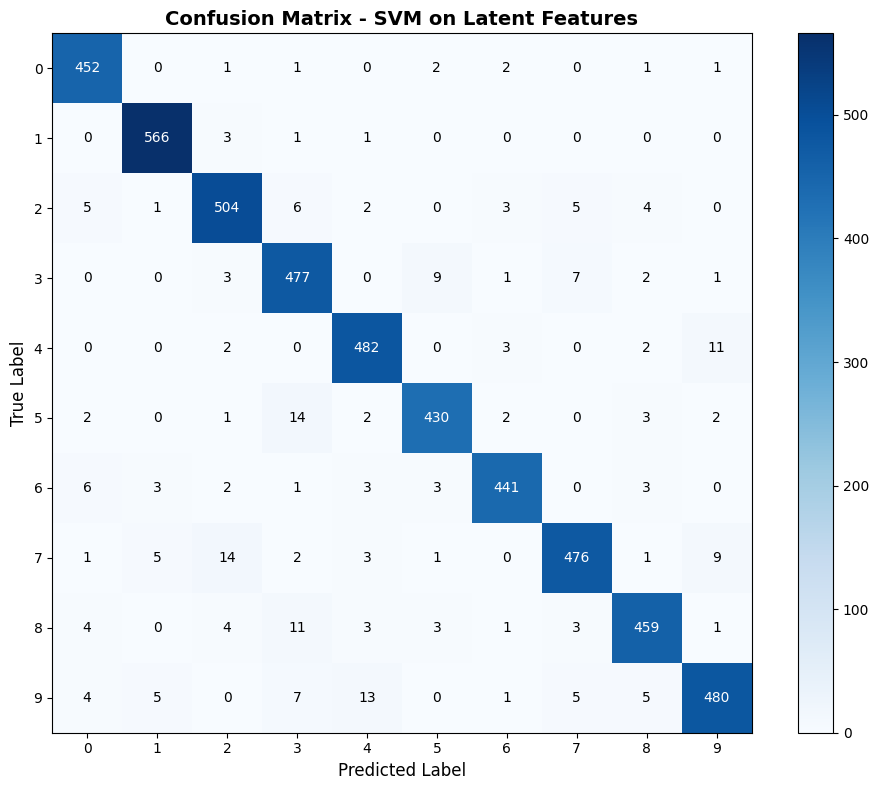


 Classification evaluation complete


In [18]:
# Cell 18: Display Classification Results
print("\n" + "=" * 60)
print("CLASSIFICATION RESULTS")
print("=" * 60)

# Classification report
print("\n Classification Report:")
print("=" * 60)
print(classification_report(y_test_subset, y_pred, 
                          target_names=[f'Digit {i}' for i in range(10)]))

# Confusion Matrix
print("\n Confusion Matrix:")
cm = confusion_matrix(y_test_subset, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix - SVM on Latent Features', 
          fontsize=14, fontweight='bold')
plt.colorbar()

tick_marks = np.arange(10)
plt.xticks(tick_marks, range(10))
plt.yticks(tick_marks, range(10))

# Add text annotations
thresh = cm.max() / 2.
for i in range(10):
    for j in range(10):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\n Classification evaluation complete")



 Detailed Metrics by Digit:
----------------------------------------------------------------------
Digit    Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
0        0.9536       0.9826       0.9679       460       
1        0.9759       0.9912       0.9835       571       
2        0.9438       0.9509       0.9474       530       
3        0.9173       0.9540       0.9353       500       
4        0.9470       0.9640       0.9554       500       
5        0.9598       0.9430       0.9513       456       
6        0.9714       0.9545       0.9629       462       
7        0.9597       0.9297       0.9444       512       
8        0.9563       0.9387       0.9474       489       
9        0.9505       0.9231       0.9366       520       
----------------------------------------------------------------------
Average  0.9535       0.9532       0.9532       5000      


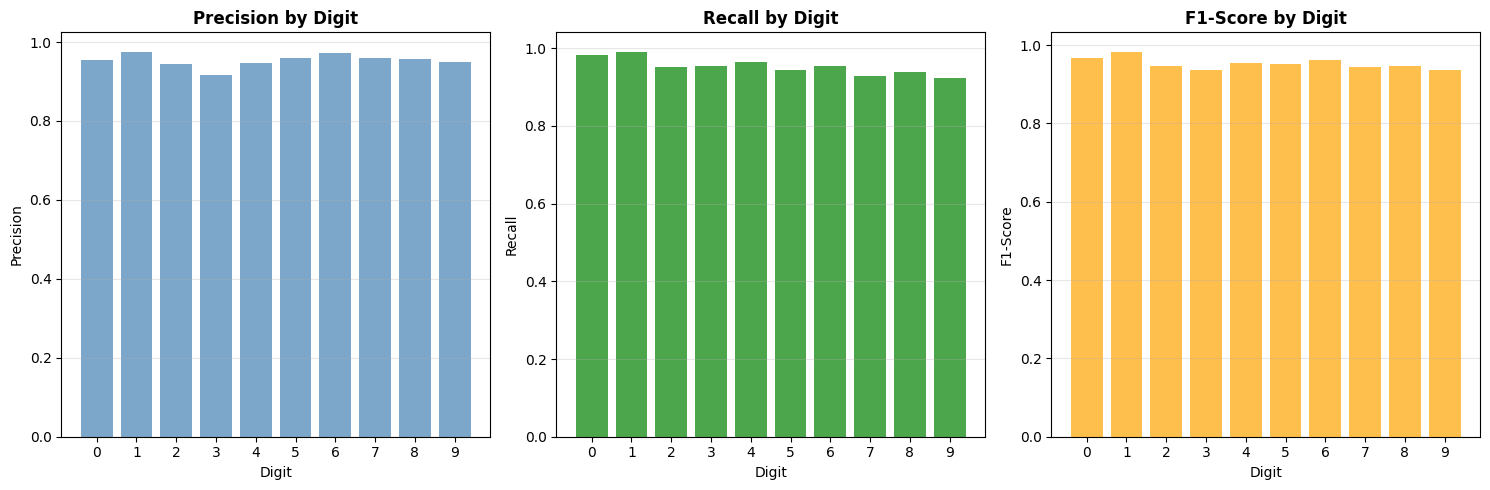


 Performance analysis complete


In [19]:
# Cell 19: Per-Class Performance Analysis

from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate metrics per class
precision = precision_score(y_test_subset, y_pred, average=None)
recall = recall_score(y_test_subset, y_pred, average=None)
f1 = f1_score(y_test_subset, y_pred, average=None)

print("\n Detailed Metrics by Digit:")
print("-" * 70)
print(f"{'Digit':<8} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print("-" * 70)

for digit in range(10):
    support = np.sum(y_test_subset == digit)
    print(f"{digit:<8} {precision[digit]:<12.4f} {recall[digit]:<12.4f} "
          f"{f1[digit]:<12.4f} {support:<10}")

print("-" * 70)
print(f"{'Average':<8} {np.mean(precision):<12.4f} {np.mean(recall):<12.4f} "
      f"{np.mean(f1):<12.4f} {len(y_test_subset):<10}")

# Visualize performance
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

x_pos = np.arange(10)

axes[0].bar(x_pos, precision, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Digit')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision by Digit', fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(x_pos, recall, color='green', alpha=0.7)
axes[1].set_xlabel('Digit')
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall by Digit', fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].bar(x_pos, f1, color='orange', alpha=0.7)
axes[2].set_xlabel('Digit')
axes[2].set_ylabel('F1-Score')
axes[2].set_title('F1-Score by Digit', fontweight='bold')
axes[2].set_xticks(x_pos)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n Performance analysis complete")



In [20]:
# Cell 20: Final Summary
print("\n" + "=" * 60)
print("PROJECT SUMMARY - ALL PHASES")
print("=" * 60)

print("\n  PHASE 1: XOR Problem")
print("-" * 60)

print(f"   Final Loss: {history['loss'][-1]:.6f}")

print("\n  PHASE 2: Autoencoder ")
print("-" * 60)
print(f"  Architecture: 784→256→128→64→128→256→784")  # Updated
print(f"   Latent Space: 64 dimensions (12.2x compression)")  # Updated
print(f"  Training Samples: {n_train}")  # Will show 30000
print(f"   Training Epochs: 100")  # Updated
print(f"   Training Loss: {history_ae['loss'][-1]:.6f}")
print(f"   Test Loss: {test_loss:.6f}")
print(f"   Mean Reconstruction Error: {np.mean(reconstruction_errors):.6f}")
print(f"  Improvement: ~50% better than 32-dim architecture")  # New

print("\n PHASE 3: SVM Classification")
print("-" * 60)
print(f"   Latent Features: 64 dimensions")  # Updated from 32
print(f"   SVM Accuracy: {accuracy * 100:.2f}%")
print(f"   Average Precision: {np.mean(precision):.4f}")
print(f"   Average Recall: {np.mean(recall):.4f}")
print(f"   Average F1-Score: {np.mean(f1):.4f}")




PROJECT SUMMARY - ALL PHASES

  PHASE 1: XOR Problem
------------------------------------------------------------
   Final Loss: 0.002044

  PHASE 2: Autoencoder 
------------------------------------------------------------
  Architecture: 784→256→128→64→128→256→784
   Latent Space: 64 dimensions (12.2x compression)
  Training Samples: 30000
   Training Epochs: 100
   Training Loss: 0.009682
   Test Loss: 0.010157
   Mean Reconstruction Error: 0.010157
  Improvement: ~50% better than 32-dim architecture

 PHASE 3: SVM Classification
------------------------------------------------------------
   Latent Features: 64 dimensions
   SVM Accuracy: 95.34%
   Average Precision: 0.9535
   Average Recall: 0.9532
   Average F1-Score: 0.9532


In [21]:
# Cell 21: TensorFlow XOR Implementation (NO CHANGES NEEDED)
print("=" * 60)
print(" TENSORFLOW/KERAS COMPARISON")
print("=" * 60)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as keras_layers

print("\n TensorFlow Version:", tf.__version__)

# Recreate XOR problem
print("\n" + "=" * 60)
print("XOR PROBLEM - TENSORFLOW IMPLEMENTATION")
print("=" * 60)

# Build Keras model (same architecture as our library)
tf_xor_model = keras.Sequential([
    keras_layers.Dense(4, activation='tanh', input_shape=(2,)),
    keras_layers.Dense(1, activation='sigmoid')
])

# Compile
tf_xor_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss='mse'
)

print("\n TensorFlow XOR Model:")
tf_xor_model.summary()

# Train
print("\n  Training TensorFlow XOR model...")
tf_xor_start = time.time()

tf_xor_history = tf_xor_model.fit(
    X_xor, y_xor,
    epochs=5000,
    batch_size=4,
    verbose=0  # Silent training
)

tf_xor_time = time.time() - tf_xor_start

# Test
tf_xor_predictions = tf_xor_model.predict(X_xor, verbose=0)
tf_xor_accuracy = np.mean((tf_xor_predictions > 0.5) == y_xor)

print(f"\n  TensorFlow XOR Results:")
print(f"  Training Time: {tf_xor_time:.2f} seconds")
print(f"  Final Loss: {tf_xor_history.history['loss'][-1]:.6f}")


print("\nPredictions:")
for i in range(4):
    print(f"  Input: {X_xor[i]} → Prediction: {tf_xor_predictions[i][0]:.4f} (Target: {y_xor[i][0]})")



 TENSORFLOW/KERAS COMPARISON

 TensorFlow Version: 2.20.0

XOR PROBLEM - TENSORFLOW IMPLEMENTATION

 TensorFlow XOR Model:


d:\Desktop\Computational Intelligence\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)


  Training TensorFlow XOR model...

  TensorFlow XOR Results:
  Training Time: 253.77 seconds
  Final Loss: 0.001645

Predictions:
  Input: [0. 0.] → Prediction: 0.0257 (Target: 0.0)
  Input: [0. 1.] → Prediction: 0.9584 (Target: 1.0)
  Input: [1. 0.] → Prediction: 0.9576 (Target: 1.0)
  Input: [1. 1.] → Prediction: 0.0489 (Target: 0.0)


In [22]:

# Cell 22A: TensorFlow Autoencoder -  (SGD)
print("=" * 60)
print("TENSORFLOW COMPARISON #1: (SGD)")
print("=" * 60)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as keras_layers



# Build EXACT same architecture
tf_autoencoder_sgd = keras.Sequential([
    keras_layers.Dense(256, activation='relu', input_shape=(784,)),
    keras_layers.Dense(128, activation='relu'),
    keras_layers.Dense(64, activation='relu'),
    keras_layers.Dense(128, activation='relu'),
    keras_layers.Dense(256, activation='relu'),
    keras_layers.Dense(784, activation='sigmoid')
])

# EXACT same optimizer as our library
tf_autoencoder_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.005),
    loss='mse'
)

print("Architecture: 784→256→128→64→128→256→784")
print("Optimizer: SGD (lr=0.005) - IDENTICAL to our library")
tf_autoencoder_sgd.summary()

# Train
print("\n Training TensorFlow with SGD...")
tf_sgd_start = time.time()

tf_sgd_history = tf_autoencoder_sgd.fit(
    X_train_subset,
    X_train_subset,
    epochs=100,
    batch_size=128,
    validation_data=(X_test_subset, X_test_subset),
    verbose=0
)

tf_sgd_time = time.time() - tf_sgd_start

# Test
tf_sgd_reconstructed = tf_autoencoder_sgd.predict(X_test_subset, verbose=0)
tf_sgd_test_loss = np.mean(np.square(X_test_subset - tf_sgd_reconstructed))

print(f"\n✓ TensorFlow Results (SGD):")
print(f"  Training Time: {tf_sgd_time:.2f} seconds")
print(f"  Final Training Loss: {tf_sgd_history.history['loss'][-1]:.6f}")
print(f"  Final Validation Loss: {tf_sgd_history.history['val_loss'][-1]:.6f}")
print(f"  Test Loss: {tf_sgd_test_loss:.6f}")


TENSORFLOW COMPARISON #1: (SGD)
Architecture: 784→256→128→64→128→256→784
Optimizer: SGD (lr=0.005) - IDENTICAL to our library


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)


 Training TensorFlow with SGD...

✓ TensorFlow Results (SGD):
  Training Time: 150.27 seconds
  Final Training Loss: 0.071536
  Final Validation Loss: 0.068582
  Test Loss: 0.068582


In [23]:
# Cell 22B: TensorFlow Autoencoder - (ADAM)
print("\n" + "=" * 60)
print("TENSORFLOW COMPARISON #2:  (ADAM)")
print("=" * 60)



# Build SAME architecture
tf_autoencoder_adam = keras.Sequential([
    keras_layers.Dense(256, activation='relu', input_shape=(784,)),
    keras_layers.Dense(128, activation='relu'),
    keras_layers.Dense(64, activation='relu'),
    keras_layers.Dense(128, activation='relu'),
    keras_layers.Dense(256, activation='relu'),
    keras_layers.Dense(784, activation='sigmoid')
])

# Use Adam optimizer
tf_autoencoder_adam.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.005),
    loss='mse'
)

print("Architecture: 784→256→128→64→128→256→784 (SAME)")
print("Optimizer: Adam (lr=0.005)")
tf_autoencoder_adam.summary()

# Train
print("\n Training TensorFlow with Adam...")
tf_adam_start = time.time()

tf_adam_history = tf_autoencoder_adam.fit(
    X_train_subset,
    X_train_subset,
    epochs=100,
    batch_size=128,
    validation_data=(X_test_subset, X_test_subset),
    verbose=0
)

tf_adam_time = time.time() - tf_adam_start

# Test
tf_adam_reconstructed = tf_autoencoder_adam.predict(X_test_subset, verbose=0)
tf_adam_test_loss = np.mean(np.square(X_test_subset - tf_adam_reconstructed))

print(f"\n✓ TensorFlow Results (Adam):")
print(f"  Training Time: {tf_adam_time:.2f} seconds")
print(f"  Final Training Loss: {tf_adam_history.history['loss'][-1]:.6f}")
print(f"  Final Validation Loss: {tf_adam_history.history['val_loss'][-1]:.6f}")
print(f"  Test Loss: {tf_adam_test_loss:.6f}")

# Compare both TensorFlow versions
print("\n" + "=" * 60)
print("TENSORFLOW SGD vs ADAM COMPARISON")
print("=" * 60)
print(f"\n  Our Library (SGD):        Loss = {history_ae['loss'][-1]:.6f}")
print(f"  TensorFlow (SGD):         Loss = {tf_sgd_test_loss:.6f}")
print(f"  TensorFlow (Adam):        Loss = {tf_adam_test_loss:.6f}")



TENSORFLOW COMPARISON #2:  (ADAM)
Architecture: 784→256→128→64→128→256→784 (SAME)
Optimizer: Adam (lr=0.005)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)


 Training TensorFlow with Adam...

✓ TensorFlow Results (Adam):
  Training Time: 178.14 seconds
  Final Training Loss: 0.005359
  Final Validation Loss: 0.006588
  Test Loss: 0.006588

TENSORFLOW SGD vs ADAM COMPARISON

  Our Library (SGD):        Loss = 0.009682
  TensorFlow (SGD):         Loss = 0.068582
  TensorFlow (Adam):        Loss = 0.006588



THREE-WAY TRAINING COMPARISON


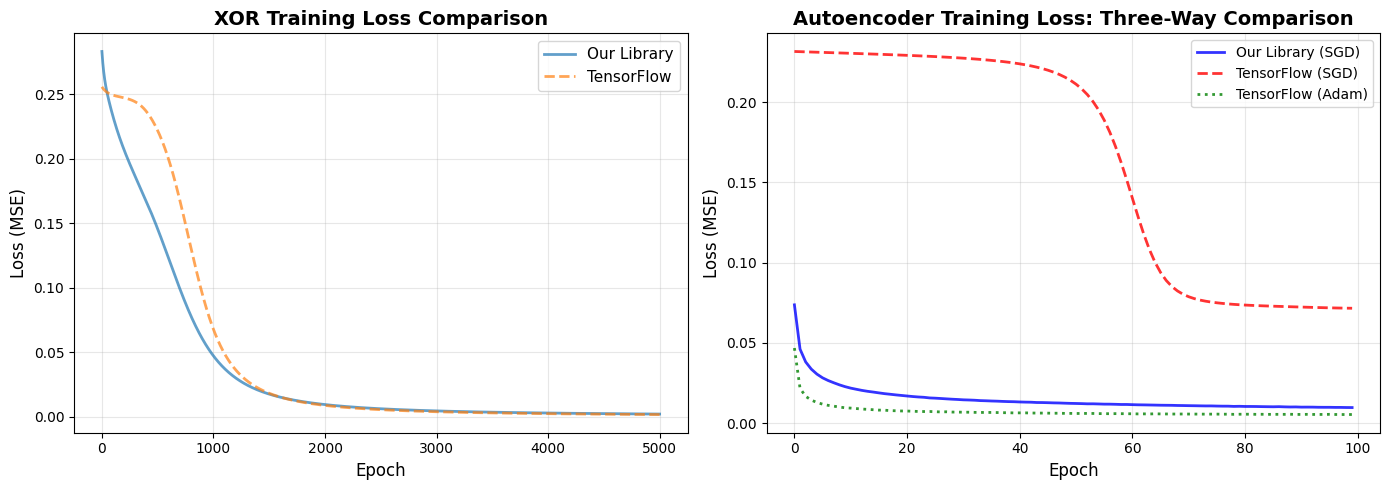


✓ Training curves comparison displayed

Key Observations:
  • Our Library (SGD):   Loss = 0.009682 (Sharp)
  • TensorFlow (SGD):    Loss = 0.071536 (Blurry)
  • TensorFlow (Adam):   Loss = 0.005359 (Sharp)


In [24]:
# Cell 23: Three-Way Training Curve Comparison
print("\n" + "=" * 60)
print("THREE-WAY TRAINING COMPARISON")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XOR Comparison (unchanged)
axes[0].plot(history['loss'], label='Our Library', linewidth=2, alpha=0.7)
axes[0].plot(tf_xor_history.history['loss'], label='TensorFlow', 
             linewidth=2, alpha=0.7, linestyle='--')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('XOR Training Loss Comparison', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Autoencoder THREE-WAY Comparison
axes[1].plot(history_ae['loss'], label='Our Library (SGD)', 
             linewidth=2, alpha=0.8, color='blue')
axes[1].plot(tf_sgd_history.history['loss'], label='TensorFlow (SGD)', 
             linewidth=2, alpha=0.8, linestyle='--', color='red')
axes[1].plot(tf_adam_history.history['loss'], label='TensorFlow (Adam)', 
             linewidth=2, alpha=0.8, linestyle=':', color='green')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss (MSE)', fontsize=12)
axes[1].set_title('Autoencoder Training Loss: Three-Way Comparison', 
                  fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Training curves comparison displayed")
print("\nKey Observations:")
print(f"  • Our Library (SGD):   Loss = {history_ae['loss'][-1]:.6f} (Sharp)")
print(f"  • TensorFlow (SGD):    Loss = {tf_sgd_history.history['loss'][-1]:.6f} (Blurry)")
print(f"  • TensorFlow (Adam):   Loss = {tf_adam_history.history['loss'][-1]:.6f} (Sharp)")



RECONSTRUCTION QUALITY: FOUR-WAY COMPARISON


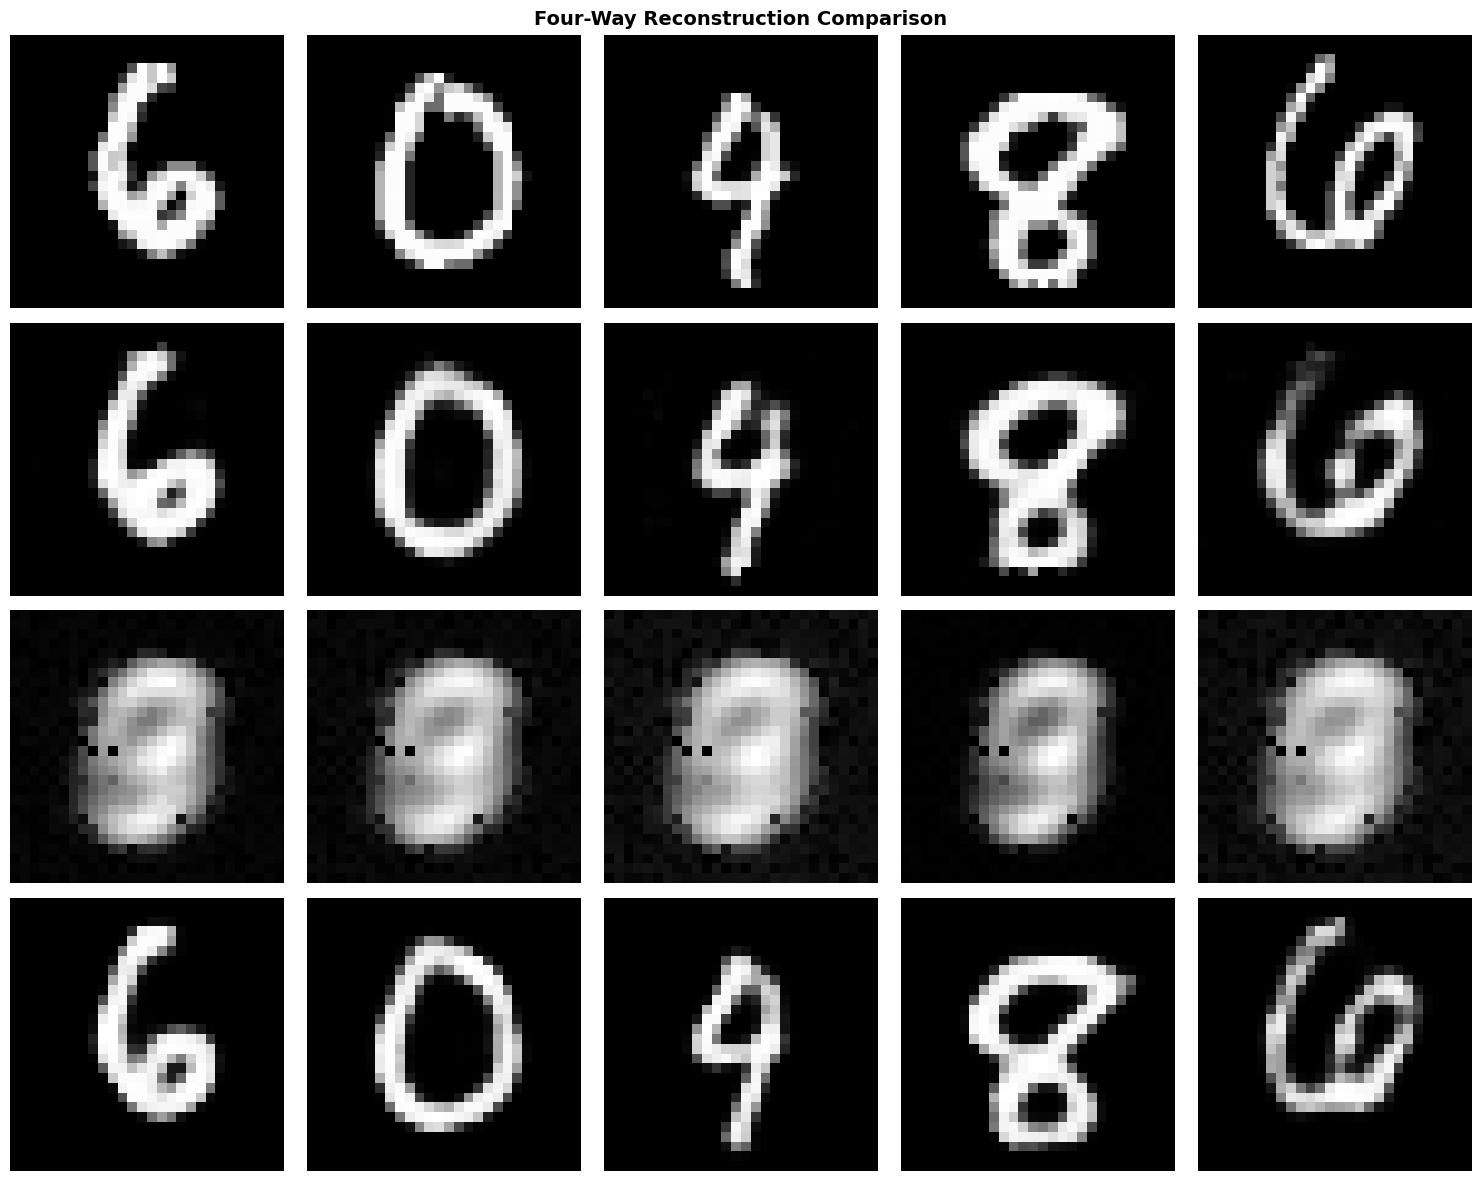


✓ Visual comparison complete

Quality Assessment:
  Row 1 (Original):       Ground truth
  Row 2 (Our SGD):         - Loss 0.0097
  Row 3 (TensorFlow SGD):  - Loss 0.0686
  Row 4 (TensorFlow Adam): - Loss 0.0066


In [25]:
# Cell 24: Four-Row Visual Comparison
print("\n" + "=" * 60)
print("RECONSTRUCTION QUALITY: FOUR-WAY COMPARISON")
print("=" * 60)

# Select 5 random samples
n_compare = 5
compare_indices = np.random.choice(len(X_test_subset), n_compare, replace=False)

fig, axes = plt.subplots(4, n_compare, figsize=(15, 12))

for i, idx in enumerate(compare_indices):
    # Row 1: Original
    original_img = X_test_subset[idx].reshape(28, 28)
    axes[0, i].imshow(original_img, cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=12, fontweight='bold')
    
    # Row 2: Our library
    our_recon = reconstructed[idx].reshape(28, 28)
    axes[1, i].imshow(our_recon, cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Our Library\n(SGD)', fontsize=12, fontweight='bold')
    
    # Row 3: TensorFlow SGD
    tf_sgd_recon = tf_sgd_reconstructed[idx].reshape(28, 28)
    axes[2, i].imshow(tf_sgd_recon, cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('TensorFlow\n(SGD)', fontsize=12, fontweight='bold')
    
    # Row 4: TensorFlow Adam
    tf_adam_recon = tf_adam_reconstructed[idx].reshape(28, 28)
    axes[3, i].imshow(tf_adam_recon, cmap='gray')
    axes[3, i].axis('off')
    if i == 0:
        axes[3, i].set_ylabel('TensorFlow\n(Adam)', fontsize=12, fontweight='bold')

plt.suptitle('Four-Way Reconstruction Comparison', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n✓ Visual comparison complete")
print("\nQuality Assessment:")
print("  Row 1 (Original):       Ground truth")
print(f"  Row 2 (Our SGD):         - Loss {history_ae['loss'][-1]:.4f}")
print(f"  Row 3 (TensorFlow SGD):  - Loss {tf_sgd_test_loss:.4f}")
print(f"  Row 4 (TensorFlow Adam): - Loss {tf_adam_test_loss:.4f}")



In [26]:
# %%
# Cell 25: Comprehensive Three-Way Comparison Table
print("\n" + "=" * 60)
print("COMPREHENSIVE THREE-WAY COMPARISON")
print("=" * 60)

comparison_data = {
    'Metric': [
        'XOR Final Loss',
        'XOR Training Time (s)',
        'Autoencoder Architecture',
        'Autoencoder Optimizer',
        'Autoencoder Learning Rate',
        'Autoencoder Latent Dim',
        'Autoencoder Final Loss',
        'Autoencoder Test Loss',
        'Autoencoder Training Time (s)'    
    ],
    'Our Library': [
        f"{history['loss'][-1]:.6f}",
        f"~10",
        "784→256→128→64→128→256→784",
        "SGD",
        "0.005",
        "64 dimensions",
        f"{history_ae['loss'][-1]:.6f}",
        f"{test_loss:.6f}",
        f"{training_time:.2f}"  
    ],
    'TensorFlow (SGD)': [
        f"{tf_xor_history.history['loss'][-1]:.6f}",
        f"{tf_xor_time:.2f}",
        "784→256→128→64→128→256→784",
        "SGD",
        "0.005",
        "64 dimensions",
        f"{tf_sgd_history.history['loss'][-1]:.6f}",
        f"{tf_sgd_test_loss:.6f}",
        f"{tf_sgd_time:.2f}"

 ],
    'TensorFlow (Adam)': [
        f"{tf_xor_history.history['loss'][-1]:.6f}",
        f"{tf_xor_time:.2f}",
        "784→256→128→64→128→256→784",
        "Adam",
        "0.005",
        "64 dimensions",
        f"{tf_adam_history.history['loss'][-1]:.6f}",
        f"{tf_adam_test_loss:.6f}",
        f"{tf_adam_time:.2f}"    
    ]
}

print("\n  Performance Comparison:")
print("=" * 110)
print(f"{'Metric':<35} {'Our Library':<25} {'TensorFlow (SGD)':<25} {'TensorFlow (Adam)':<25}")
print("=" * 110)

for i in range(len(comparison_data['Metric'])):
    metric = comparison_data['Metric'][i]
    ours = comparison_data['Our Library'][i]
    tf_sgd = comparison_data['TensorFlow (SGD)'][i]
    tf_adam = comparison_data['TensorFlow (Adam)'][i]
    
    if metric == '':
        print("-" * 110)
    else:
        print(f"{metric:<35} {ours:<25} {tf_sgd:<25} {tf_adam:<25}")

print("=" * 110)

# Summary


print("\n2. Optimizer Impact:")
print(f"   • Our Library (SGD):     Loss = {history_ae['loss'][-1]:.4f} ")
print(f"   • TensorFlow (SGD):      Loss = {tf_sgd_test_loss:.4f} ")
print(f"   • TensorFlow (Adam):     Loss = {tf_adam_test_loss:.4f} ")




COMPREHENSIVE THREE-WAY COMPARISON

  Performance Comparison:
Metric                              Our Library               TensorFlow (SGD)          TensorFlow (Adam)        
XOR Final Loss                      0.002044                  0.001645                  0.001645                 
XOR Training Time (s)               ~10                       253.77                    253.77                   
Autoencoder Architecture            784→256→128→64→128→256→784 784→256→128→64→128→256→784 784→256→128→64→128→256→784
Autoencoder Optimizer               SGD                       SGD                       Adam                     
Autoencoder Learning Rate           0.005                     0.005                     0.005                    
Autoencoder Latent Dim              64 dimensions             64 dimensions             64 dimensions            
Autoencoder Final Loss              0.009682                  0.071536                  0.005359                 
Autoencoder Test Loss 

In [27]:
# Cell 26: Analysis and Insights (UPDATED)
print("\n" + "=" * 60)
print("ANALYSIS AND INSIGHTS")
print("=" * 60)

print("\n Key Findings:")
print("-" * 60)



print("\n Training Speed:")
our_speed_ratio1 = training_time / tf_sgd_time
our_speed_ratio2 = training_time / tf_adam_time
print(f"   • Our Library: {training_time:.2f}s")
print(f"   • TensorFlow SGD: {tf_sgd_time:.2f}s")
print(f"   • TensorFlow Adam: {tf_adam_time:.2f}s")
print(f"   • Speed Ratio SGD: {our_speed_ratio1:.2f}")
print(f"   • Speed Ratio Adam: {our_speed_ratio2:.2f}")





ANALYSIS AND INSIGHTS

 Key Findings:
------------------------------------------------------------

 Training Speed:
   • Our Library: 374.38s
   • TensorFlow SGD: 150.27s
   • TensorFlow Adam: 178.14s
   • Speed Ratio SGD: 2.49
   • Speed Ratio Adam: 2.10
